## **Mục tiêu và phạm vi thu thập**
* Mục tiêu: thu thập dữ liệu tin rao bán nhà đất tại TP.HCM phục vụ mục tiêu: “Phân tích các yếu tố ảnh hưởng tới giá nhà và dự báo xu hướng giá nhà”
* Phạm vi: 4 nguồn công khai: batdongsan, alonhadat, meeyland và nhadat24h
* Đối tượng: các tin rao bán, cho thuê nhà đất, căn hộ … tại TP.HCM

## **Mục tiêu chính của notebook này bao gồm:**
* Khám phá (EDA): Tìm hiểu các đặc điểm chính của dữ liệu như phân phối giá, diện tích, vị trí ...
* Làm sạch: Tiền xử lý dữ liệu để đảm bảo tính chính xác và nhất quán cho việc phân tích.


### **1. Mô tả dữ liệu**

*Nguồn dữ liệu cho phân tích này là tập hợp dữ liệu bất động sản từ 4 nguồn công khai lớn tại Việt Nam: batdongsan, alonhadat, meeyland và nhadat24h . Bộ dữ liệu bao gồm các thuộc tính cơ bản của một bất động sản cho thuê, cụ thể:*

* **Tiêu đề:** Tiêu đề của tin đăng bất động sản.
* **Giá:** Giá bán của bất động sản.
* **Diện tích:** Tổng diện tích của bất động sản, đơn vị tính là mét vuông (m²).
* **Giá/m2:** Đơn giá tham khảo trên một mét vuông.
* **Địa chỉ:** Địa chỉ của bất động sản.
* **Ngày đăng:** Ngày đăng tin bất động sản.
* **Số phòng ngủ:** Tổng số lượng phòng ngủ trong bất động sản.
* **Số phòng vệ sinh:** Tổng số lượng phòng vệ sinh.
* **Số phòng tắm:** Số lượng phòng tắm.
* **Số tầng:** Tổng số tầng của công trình nhà ở.
* **Chỗ để xe:** Thông tin về nơi đỗ xe 
* **Kích thước:** Kích thước của bất động sản, thường là chiều rộng x chiều dài
* **Mặt tiền:** Chiều rộng mặt tiền của bất động sản, đơn vị tính là mét (m).
* **Đường vào:** Chiều rộng của đường/ngõ đi vào bất động sản, đơn vị tính là mét (m).
* **Loại BĐS:** Phân loại hình thái của bất động sản.
* **Nguồn:** Website nguồn thu thập dữ liệu (alonhadat, batdongsan, meeyland, nhadat24h).

### **2. Làm Sạch và Tiền Xử Lý Dữ Liệu (Data Cleaning & Preprocessing)**

#### **2.1 Nhập dữ liệu và cài đặt**

In [29]:
import pandas as pd
import numpy as np
import unicodedata
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


#### **2.2. Đọc Dữ Liệu và Khảo Sát Ban Đầu**

In [30]:
current_dir = Path(os.getcwd())
file_path = current_dir.parent /'file_clean'/'fulldata_raw_4web.csv'
df_raw = pd.read_csv(file_path, encoding='utf-8-sig')

print(f"Shape ban đầu: {df_raw.shape}")
print("\nPHÂN BỐ DỮ LIỆU BAN ĐẦU:")
print("\nTheo Nguồn:")
print(df_raw['Nguồn'].value_counts())

print(f"\nSố dòng: {len(df_raw):,} | Số cột: {len(df_raw.columns)}")
display(df_raw.head(3))

Shape ban đầu: (163538, 16)

PHÂN BỐ DỮ LIỆU BAN ĐẦU:

Theo Nguồn:
Nguồn
batdongsan    76748
nhadat24h     59913
alonhadat     17537
meeyland       9340
Name: count, dtype: int64

Số dòng: 163,538 | Số cột: 16


,Tiêu đề,Giá,Diện tích,Giá/m2,Địa chỉ,Ngày đăng,Số phòng ngủ,Số phòng vệ sinh,Số phòng tắm,Số tầng,Chỗ để xe,Kích thước,Mặt tiền,Đường vào,Loại BĐS,Nguồn
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,630 triệu,120 m²,NaN,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",08/10/2025,3.0,NaN,NaN,1.0,Có,6x19m,NaN,8m,NaN,alonhadat
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đan...,650 triệu,120 m²,NaN,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",08/10/2025,3.0,NaN,NaN,2.0,Không,6x20m,NaN,8m,NaN,alonhadat
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5...","5,85 tỷ",123 m²,NaN,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",08/10/2025,NaN,NaN,NaN,NaN,Không,6x23m,NaN,10m,NaN,alonhadat


#### **2.3. Kiểm tra kiểu dữ liệu**

In [31]:
print(f"Kiểu dữ liệu ban đầu:\n")
print(df_raw.dtypes)

Kiểu dữ liệu ban đầu:

Tiêu đề              object
Giá                  object
Diện tích            object
Giá/m2               object
Địa chỉ              object
Ngày đăng            object
Số phòng ngủ        float64
Số phòng vệ sinh    float64
Số phòng tắm        float64
Số tầng              object
Chỗ để xe            object
Kích thước           object
Mặt tiền             object
Đường vào            object
Loại BĐS             object
Nguồn                object
dtype: object


* **Nhận xét:**
    * Các cột đã đúng định dạng số: `Số phòng ngủ`, `Số phòng vệ sinh`, `Số phòng tắm`.
    * Các cột quan trọng bị sai định dạng (object): `Giá`, `Diện tích`, `Giá/m2`, `Số tầng`, `Mặt tiền`, `Đường vào`.
    * Các cột cần xử lý đặc biệt:
        * `Ngày đăng`: Cần chuyển sang `datetime`.
        * `Kích thước`: Cần tách thành `Chiều rộng`, `Chiều dài`.
        * `Địa chỉ`: Cần tách thành `Quận`.
        * `Loại BĐS`: Cần chuẩn hóa và suy luận từ cột `Tiêu đề` 
* **Nguyên nhân:** Dữ liệu thô chứa ký tự chữ, đơn vị ("triệu", "tỷ", "m²", "m"), hoặc giá trị text ("Thỏa thuận").
* **Bước tiếp theo:** Tiền xử lý để làm sạch và chuyển đổi các cột này về đúng định dạng.

#### **2.4. Kiểm tra và xử lý dữ liệu trùng lặp**

In [32]:
# Kiểm tra dữ liệu xem có tồn tại dòng dữ liệu nào bị trùng lặp hay không 
sum(df_raw.duplicated())

0

* Không có dòng nào bị trùng lặp hoàn toàn, ổn

#### **2.5. Phân Tích Giá Trị Thiếu (Missing Values)**

##### **2.5.1. Tỷ lệ thiếu tổng thể**

In [33]:
# Tỉ lệ giá trị bị thiếu ở mỗi cột
df_raw.isnull().sum() / len(df_raw)

Tiêu đề             0.000000
Giá                 0.000000
Diện tích           0.000006
Giá/m2              0.512291
Địa chỉ             0.000006
Ngày đăng           0.000073
Số phòng ngủ        0.447780
Số phòng vệ sinh    0.484762
Số phòng tắm        0.968821
Số tầng             0.754638
Chỗ để xe           0.526410
Kích thước          0.904622
Mặt tiền            0.765944
Đường vào           0.645128
Loại BĐS            0.751361
Nguồn               0.000000
dtype: float64

* Dữ liệu tốt, không thiếu: Tiêu đề, Giá, Diện tích, Địa chỉ, Ngày đăng, Nguồn
* Dữ liệu thiếu nghiêm trọng (Lý do cào nhiều trang web, một số trang không có dữ liệu của trang web khác nên dẫn tới dữ liệu một số cột bị thiếu nặng nề)
    * Số phòng tắm: 96,8%
    * Kích thước: 90,4%
    * Mặc tiền: 76,5%
    * Số tầng: 75,4%
    * Loại BĐS: 75,1%
    * Đương vào: 64.5%
* Dữ liệu cân nhắc:
    * Chỗ để xe:: 52,6%
    * Số phòng vệ sinh: 48.4%
    * Số phòng ngủ: 44.7%
* Giá/m2: tái tại được vì Giá / Diện tích = Giá/m2 (Giá và Diện tích gần như là đầy đủ, không bị thiếu dữ liệu)

##### **2.5.2. Tỷ lệ thiếu theo từng nguồn**

In [34]:
print("\n THỐNG KÊ GIÁ TRỊ THIẾU THEO NGUỒN:\n")
for src in df_raw['Nguồn'].unique():
    sub = df_raw[df_raw['Nguồn'] == src]
    missing_src_stats = pd.DataFrame({
        'Missing': sub.isna().sum(),
        'Percent_%': (sub.isna().sum() / len(sub) * 100).round(2)
    }).sort_values('Percent_%', ascending=False)

    print(f"\n=== {src.upper()} ({len(sub):,} dòng) ===")
    display(missing_src_stats[missing_src_stats['Missing'] > 0])


 THỐNG KÊ GIÁ TRỊ THIẾU THEO NGUỒN:


=== ALONHADAT (17,537 dòng) ===


,Missing,Percent_%
Giá/m2,17537,100.00
Số phòng vệ sinh,17537,100.00
Số phòng tắm,17537,100.00
Mặt tiền,17537,100.00
Loại BĐS,17537,100.00
Kích thước,1939,11.06
Số tầng,1772,10.10
Số phòng ngủ,1466,8.36
Đường vào,60,0.34



=== BATDONGSAN (76,748 dòng) ===


,Missing,Percent_%
Số phòng tắm,76748,100.00
Số tầng,76748,100.00
Chỗ để xe,76748,100.00
Kích thước,76748,100.00
Mặt tiền,76748,100.00
Đường vào,76748,100.00
Loại BĐS,76748,100.00
Số phòng vệ sinh,29009,37.80
Số phòng ngủ,26509,34.54
Giá/m2,6039,7.87



=== MEEYLAND (9,340 dòng) ===


,Missing,Percent_%
Số phòng vệ sinh,9340,100.00
Số tầng,9340,100.00
Chỗ để xe,9340,100.00
Kích thước,9340,100.00
Mặt tiền,9340,100.00
Đường vào,9340,100.00
Loại BĐS,9340,100.00
Số phòng tắm,4241,45.41
Số phòng ngủ,3629,38.85
Giá/m2,290,3.10



=== NHADAT24H (59,913 dòng) ===


,Missing,Percent_%
Giá/m2,59913,100.00
Số phòng tắm,59913,100.00
Kích thước,59913,100.00
Số phòng ngủ,41625,69.48
Số tầng,35552,59.34
Số phòng vệ sinh,23391,39.04
Mặt tiền,21636,36.11
Đường vào,19355,32.31
Loại BĐS,19251,32.13


* Alonhadat: Thiếu hoàn toàn Giá/m2, Số phòng vệ sinh, Số phòng tắm, Mặt tiền, Loại BĐS
* Batdongsan: Thiếu hoàn toàn Số phòng tắm, Số tầng, Chỗ đề xe, Kích thước, Mặt tiền, Đường vào, Loại BĐS
* Meeyland: Thiếu hoàn toàn các trường tương tự như batdongsan
* Nhadat24h: Có dữ liệu đầy đủ nhất, chỉ thiếu Giá/m2 và Số phòng tắm và Kích thước



### **3. Xây Dựng Các Hàm Tiền Xử Lý**

*Các hàm tiện ích này được xây dựng để chuyển đổi dữ liệu thô về đúng kiểu dữ liệu và thống nhất định dạng trước khi phân tích.*

#### **3.1. Chuẩn hóa giá, diện tích, kích thước, số đo**

**Mục đích:** Đưa các giá trị dạng text (ví dụ: "5,8 tỷ", "120 m²", "6x19m", "8m") về dạng số (numeric) để có thể tính toán.

**Giải thích:**
* Sử dụng hàm `parse_number` để trích xuất số từ chuỗi, xử lý cả dấu phẩy và dấu chấm thập phân.
* Hàm `clean_gia` chuyển đổi "tỷ", "triệu" thành giá trị số VND đầy đủ. Xử lý cả trường hợp "thỏa thuận".
* Hàm `clean_dien_tich` lấy số diện tích từ chuỗi (ví dụ: "120 m²" -> 120.0).
* Hàm `tach_kich_thuoc` tách chuỗi dạng "RxD" (ví dụ: "6x19m") thành hai cột số `ChieuRong` và `ChieuDai`.
* Các cột số đo như `Mặt tiền`, `Đường vào` cũng dùng `clean_dien_tich` (hoặc `parse_number`) để lấy giá trị số.

In [35]:
# parse_number: chuẩn hóa chuỗi số -> float
def parse_number(token):
    """Parse số từ string, xử lý dấu . và , -> trả float hoặc None"""
    if token is None:
        return None
    s = str(token).strip()
    # giữ chỉ chữ số, dấu chấm, dấu phẩy
    s = re.sub(r'[^\d\.,]', '', s)
    if not s:
        return None
    # Trường hợp có cả '.' và ',' => ví dụ "1.234,56" (VN) -> '1234.56'
    if '.' in s and ',' in s:
        s = s.replace('.', '').replace(',', '.')
    # Trường hợp "1,234.56" (US) -> giữ nguyên
    # elif '.' in s and ',' in s and s.find(',') < s.find('.'):
    #      s = s.replace(',', '') # Bỏ qua cách này vì dữ liệu VN chủ yếu
    # Trường hợp chỉ có '.' làm phân cách ngàn "1.200.000" -> xóa dấu chấm
    elif '.' in s and s.count('.') > 1:
         s = s.replace('.', '')
    # Trường hợp chỉ có ',' làm phân cách thập phân "1,5" -> "1.5"
    elif ',' in s and s.count(',') == 1:
        s = s.replace(',', '.')
    # Trường hợp chỉ có ',' làm phân cách ngàn "1,200,000" -> xóa dấu phẩy
    elif ',' in s and s.count(',') > 1:
         s = s.replace(',', '')
    try:
        # Kiểm tra nếu chuỗi rỗng sau khi xử lý
        if not s:
            return None
        return float(s)
    except ValueError:
        return None

In [36]:
# Clean Giá
def clean_gia(x):
    """Chuyển 'Giá' nhiều định dạng về VND (float) hoặc None"""
    if pd.isna(x):
        return None
    s = str(x).lower().strip()
    if 'thỏa' in s or 'thoa' in s or 'thương lượng' in s:  # Thỏa Thuận -> None
        return None

    # Tìm số đầu tiên (có thể có dấu . ,)
    num_match = re.search(r'[\d\.,]+', s)
    if not num_match:
        return None

    num_str = num_match.group(0)
    num = parse_number(num_str)
    if num is None:
        return None

    # Quy đổi đơn vị
    if 'tỷ' in s or 'ty' in s:
        return num * 1_000_000_000
    if 'triệu' in s or 'trieu' in s or re.search(r'\btr\b', s): # Thêm \btr\b để bắt "tr" đứng riêng
        return num * 1_000_000
    if 'ngàn' in s or 'nghin' in s or 'k\b' in s: # Xử lý đơn vị ngàn/k
         return num * 1_000

    # Nếu không có đơn vị rõ ràng
    # Giả định nếu số lớn > 1 triệu thì là VND
    if num >= 1_000_000:
        return num
    if num < 1_000_000:
         # print(f"Giá trị không rõ đơn vị và nhỏ: '{x}' -> None") # Debugging
         return None

    return num # Trường hợp còn lại (vd: số lớn không có đơn vị)

    # Clean Diện tích (và các số đo khác có 'm')
def clean_dien_tich(x):
    """Parse diện tích (m2) hoặc số đo (m) từ chuỗi -> float hoặc None"""
    if pd.isna(x):
        return None
    s = str(x).lower().replace('m²', '').replace('m2', '').replace('m', '').strip()
    # Tìm số đầu tiên trong chuỗi đã loại bỏ đơn vị
    toks = re.findall(r'[\d\.,]+', s)
    return parse_number(toks[0]) if toks else None

# Tách Kích thước
def tach_kich_thuoc(x):
    """Tách kích thước '6x19' -> (6.0, 19.0) hoặc (None, None)"""
    if pd.isna(x):
        return (None, None)
    # Regex tìm kiếm linh hoạt hơn: số [dấu . ,] \s* [xX*] \s* số [dấu . ,]
    m = re.search(r'([\d\.,]+)\s*[xX\*]\s*([\d\.,]+)', str(x))
    if m:
        chieu_rong = parse_number(m.group(1))
        chieu_dai = parse_number(m.group(2))
        return (chieu_rong, chieu_dai)
    return (None, None)

#### **3.2. Chuẩn hóa địa chỉ**

**Mục đích:** Tách thông tin Quận/Huyện từ chuỗi địa chỉ dài để phục vụ phân tích theo khu vực.

**Giải thích:**
* Dữ liệu địa chỉ không có cấu trúc cố định.
* Sử dụng hàm `normalize_text` để chuẩn hóa text (bỏ dấu, chữ thường, ký tự đặc biệt).
* Tạo danh sách `LIST_QUAN` chuẩn chứa tên các Quận/Huyện/TP Thủ Đức.
* Tạo `ward_new_to_district`: một mapping từ tên Phường/Xã (đã chuẩn hóa) về tên Quận/Huyện chuẩn. *Lưu ý: danh sách này cần được bổ sung nếu dữ liệu thực tế có thêm phường/xã chưa được liệt kê.*
* Hàm `map_new_ward_to_district` là hàm chính:
    1. Chuẩn hóa địa chỉ đầu vào.
    2. **Ưu tiên 1:** Tìm tên Quận/Huyện chuẩn (`LIST_QUAN`) trực tiếp trong địa chỉ đã chuẩn hóa.
    3. **Ưu tiên 2:** Nếu không thấy Quận/Huyện, tìm các cụm "phường X", "xã Y" trong địa chỉ gốc, chuẩn hóa tên phường/xã đó và tra cứu trong `ward_new_to_district`.
    4. **Ưu tiên 3:** Nếu vẫn chưa tìm được, tìm tên phường/xã (từ `ward_new_to_district`) bất kỳ đâu trong địa chỉ đã chuẩn hóa.
    5. Nếu không tìm thấy -> trả về 'CXD' (Chưa Xác Định).
* Hàm `tach_dia_chi_final` trả về tuple `(ThanhPho, QuanHuyen, DiaChi_full)`. Hiện tại `ThanhPho` mặc định là 'Hồ Chí Minh' nếu có dấu hiệu, còn lại là None.
* Hàm `apply_to_df` áp dụng việc tách địa chỉ lên toàn bộ DataFrame.

In [37]:
LIST_QUAN = [
    'Quận 1','Quận 2','Quận 3','Quận 4','Quận 5','Quận 6','Quận 7','Quận 8','Quận 9','Quận 10',
    'Quận 11','Quận 12','Bình Tân','Bình Thạnh','Gò Vấp','Phú Nhuận','Tân Bình','Tân Phú',
    'Thành Phố Thủ Đức', 'Thủ Đức', # Thêm Thủ Đức (ngắn)
    'Huyện Nhà Bè', 'Nhà Bè', # Thêm Nhà Bè (ngắn)
    'Huyện Bình Chánh', 'Bình Chánh', # Thêm Bình Chánh (ngắn)
    'Huyện Hóc Môn', 'Hóc Môn', # Thêm Hóc Môn (ngắn)
    'Huyện Củ Chi', 'Củ Chi', # Thêm Củ Chi (ngắn)
    'Huyện Cần Giờ', 'Cần Giờ' # Thêm Cần Giờ (ngắn)
]
# Tạo map chuẩn hóa tên quận (bỏ tiền tố "Quận", "Huyện", "Thành Phố")
QUAN_MAP_CANONICAL = {
    'Quận 1': 'Quận 1', 'Quận 3': 'Quận 3', 'Quận 4': 'Quận 4', 'Quận 5': 'Quận 5',
    'Quận 6': 'Quận 6', 'Quận 7': 'Quận 7', 'Quận 8': 'Quận 8', 'Quận 10': 'Quận 10',
    'Quận 11': 'Quận 11', 'Quận 12': 'Quận 12',
    'Quận 2': 'Thủ Đức', 'Quận 9': 'Thủ Đức', 'Thủ Đức': 'Thủ Đức', 'Thành Phố Thủ Đức': 'Thủ Đức', # Gom về Thủ Đức
    'Bình Tân': 'Bình Tân', 'Bình Thạnh': 'Bình Thạnh', 'Gò Vấp': 'Gò Vấp',
    'Phú Nhuận': 'Phú Nhuận', 'Tân Bình': 'Tân Bình', 'Tân Phú': 'Tân Phú',
    'Huyện Nhà Bè': 'Nhà Bè', 'Nhà Bè': 'Nhà Bè',
    'Huyện Bình Chánh': 'Bình Chánh', 'Bình Chánh': 'Bình Chánh',
    'Huyện Hóc Môn': 'Hóc Môn', 'Hóc Môn': 'Hóc Môn',
    'Huyện Củ Chi': 'Củ Chi', 'Củ Chi': 'Củ Chi',
    'Huyện Cần Giờ': 'Cần Giờ', 'Cần Giờ': 'Cần Giờ'
}


# -------------------
# Hàm chuẩn hoá chuỗi (bỏ dấu, chữ thường, ký tự đặc biệt)
# -------------------
def normalize_text(s):
    if s is None or pd.isna(s):
        return ''
    s = str(s).strip().lower()
    s = unicodedata.normalize('NFD', s)
    s = ''.join(ch for ch in s if not unicodedata.category(ch).startswith('M'))
    # Bỏ ký tự đặc biệt nhưng giữ lại số và chữ cái tiếng Việt không dấu
    s = re.sub(r'[^0-9a-z\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip() # Chuẩn hóa khoảng trắng
    return s

# -------------------
# Mapping: phường/xã (đã chuẩn hóa) -> tên quận/huyện CHUẨN (từ QUAN_MAP_CANONICAL)
# Lưu ý: Cần bổ sung nếu thiếu
# -------------------
ward_new_to_district_normalized = {
    # Quận 1
    normalize_text('Phường Bến Thành'): 'Quận 1', normalize_text('Phường Cầu Kho'): 'Quận 1',
    normalize_text('Phường Cầu Ông Lãnh'): 'Quận 1', normalize_text('Phường Cô Giang'): 'Quận 1',
    normalize_text('Phường Đa Kao'): 'Quận 1', normalize_text('Phường Nguyễn Cư Trinh'): 'Quận 1',
    normalize_text('Phường Nguyễn Thái Bình'): 'Quận 1', normalize_text('Phường Phạm Ngũ Lão'): 'Quận 1',
    normalize_text('Phường Tân Định'): 'Quận 1', normalize_text('Phường Bến Nghé'): 'Quận 1',

    # Quận 3
    normalize_text('Phường 01'): 'Quận 3', normalize_text('Phường 02'): 'Quận 3',
    normalize_text('Phường 03'): 'Quận 3', normalize_text('Phường 04'): 'Quận 3',
    normalize_text('Phường 05'): 'Quận 3', normalize_text('Phường 09'): 'Quận 3',
    normalize_text('Phường 10'): 'Quận 3', normalize_text('Phường 11'): 'Quận 3',
    normalize_text('Phường 12'): 'Quận 3', normalize_text('Phường 13'): 'Quận 3',
    normalize_text('Phường 14'): 'Quận 3', normalize_text('Phường Võ Thị Sáu'): 'Quận 3', # Phường mới gộp
    normalize_text('Phường 6'): 'Quận 3', normalize_text('Phường 7'): 'Quận 3', normalize_text('Phường 8'): 'Quận 3', # Phường cũ

    # Quận 4
    normalize_text('Phường 1'): 'Quận 4', normalize_text('Phường 2'): 'Quận 4',
    normalize_text('Phường 3'): 'Quận 4', normalize_text('Phường 4'): 'Quận 4',
    normalize_text('Phường 6'): 'Quận 4', normalize_text('Phường 8'): 'Quận 4',
    normalize_text('Phường 9'): 'Quận 4', normalize_text('Phường 10'): 'Quận 4',
    normalize_text('Phường 13'): 'Quận 4', normalize_text('Phường 14'): 'Quận 4',
    normalize_text('Phường 15'): 'Quận 4', normalize_text('Phường 16'): 'Quận 4',
    normalize_text('Phường 18'): 'Quận 4',

    # Quận 5
    normalize_text('Phường 1'): 'Quận 5', normalize_text('Phường 2'): 'Quận 5',
    normalize_text('Phường 3'): 'Quận 5', normalize_text('Phường 4'): 'Quận 5',
    normalize_text('Phường 5'): 'Quận 5', normalize_text('Phường 6'): 'Quận 5',
    normalize_text('Phường 7'): 'Quận 5', normalize_text('Phường 8'): 'Quận 5',
    normalize_text('Phường 9'): 'Quận 5', normalize_text('Phường 10'): 'Quận 5',
    normalize_text('Phường 11'): 'Quận 5', normalize_text('Phường 12'): 'Quận 5',
    normalize_text('Phường 13'): 'Quận 5', normalize_text('Phường 14'): 'Quận 5',

    # Quận 6
    normalize_text('Phường 1'): 'Quận 6', normalize_text('Phường 2'): 'Quận 6',
    normalize_text('Phường 3'): 'Quận 6', normalize_text('Phường 4'): 'Quận 6',
    normalize_text('Phường 5'): 'Quận 6', normalize_text('Phường 6'): 'Quận 6',
    normalize_text('Phường 7'): 'Quận 6', normalize_text('Phường 8'): 'Quận 6',
    normalize_text('Phường 9'): 'Quận 6', normalize_text('Phường 10'): 'Quận 6',
    normalize_text('Phường 11'): 'Quận 6', normalize_text('Phường 12'): 'Quận 6',
    normalize_text('Phường 13'): 'Quận 6', normalize_text('Phường 14'): 'Quận 6',

    # Quận 7
    normalize_text('Phường Bình Thuận'): 'Quận 7', normalize_text('Phường Phú Mỹ'): 'Quận 7',
    normalize_text('Phường Phú Thuận'): 'Quận 7', normalize_text('Phường Tân Hưng'): 'Quận 7',
    normalize_text('Phường Tân Kiểng'): 'Quận 7', normalize_text('Phường Tân Phong'): 'Quận 7',
    normalize_text('Phường Tân Phú'): 'Quận 7', normalize_text('Phường Tân Quy'): 'Quận 7',
    normalize_text('Phường Tân Thuận Đông'): 'Quận 7', normalize_text('Phường Tân Thuận Tây'): 'Quận 7',

    # Quận 8
    normalize_text('Phường 1'): 'Quận 8', normalize_text('Phường 2'): 'Quận 8',
    normalize_text('Phường 3'): 'Quận 8', normalize_text('Phường 4'): 'Quận 8',
    normalize_text('Phường 5'): 'Quận 8', normalize_text('Phường 6'): 'Quận 8',
    normalize_text('Phường 7'): 'Quận 8', normalize_text('Phường 8'): 'Quận 8',
    normalize_text('Phường 9'): 'Quận 8', normalize_text('Phường 10'): 'Quận 8',
    normalize_text('Phường 11'): 'Quận 8', normalize_text('Phường 12'): 'Quận 8',
    normalize_text('Phường 13'): 'Quận 8', normalize_text('Phường 14'): 'Quận 8',
    normalize_text('Phường 15'): 'Quận 8', normalize_text('Phường 16'): 'Quận 8',

    # Quận 10
    normalize_text('Phường 1'): 'Quận 10', normalize_text('Phường 2'): 'Quận 10',
    normalize_text('Phường 4'): 'Quận 10', normalize_text('Phường 5'): 'Quận 10',
    normalize_text('Phường 6'): 'Quận 10', normalize_text('Phường 7'): 'Quận 10',
    normalize_text('Phường 8'): 'Quận 10', normalize_text('Phường 9'): 'Quận 10',
    normalize_text('Phường 10'): 'Quận 10', normalize_text('Phường 11'): 'Quận 10',
    normalize_text('Phường 12'): 'Quận 10', normalize_text('Phường 13'): 'Quận 10',
    normalize_text('Phường 14'): 'Quận 10', normalize_text('Phường 15'): 'Quận 10',

    # Quận 11
    normalize_text('Phường 1'): 'Quận 11', normalize_text('Phường 2'): 'Quận 11',
    normalize_text('Phường 3'): 'Quận 11', normalize_text('Phường 4'): 'Quận 11',
    normalize_text('Phường 5'): 'Quận 11', normalize_text('Phường 6'): 'Quận 11',
    normalize_text('Phường 7'): 'Quận 11', normalize_text('Phường 8'): 'Quận 11',
    normalize_text('Phường 9'): 'Quận 11', normalize_text('Phường 10'): 'Quận 11',
    normalize_text('Phường 11'): 'Quận 11', normalize_text('Phường 12'): 'Quận 11',
    normalize_text('Phường 13'): 'Quận 11', normalize_text('Phường 14'): 'Quận 11',
    normalize_text('Phường 15'): 'Quận 11', normalize_text('Phường 16'): 'Quận 11',

    # Quận 12
    normalize_text('Phường An Phú Đông'): 'Quận 12', normalize_text('Phường Đông Hưng Thuận'): 'Quận 12',
    normalize_text('Phường Hiệp Thành'): 'Quận 12', normalize_text('Phường Tân Chánh Hiệp'): 'Quận 12',
    normalize_text('Phường Tân Hưng Thuận'): 'Quận 12', normalize_text('Phường Tân Thới Hiệp'): 'Quận 12',
    normalize_text('Phường Tân Thới Nhất'): 'Quận 12', normalize_text('Phường Thạnh Lộc'): 'Quận 12',
    normalize_text('Phường Thạnh Xuân'): 'Quận 12', normalize_text('Phường Thới An'): 'Quận 12',
    normalize_text('Phường Trung Mỹ Tây'): 'Quận 12',

    # Bình Tân
    normalize_text('Phường An Lạc'): 'Bình Tân', normalize_text('Phường An Lạc A'): 'Bình Tân',
    normalize_text('Phường Bình Hưng Hòa'): 'Bình Tân', normalize_text('Phường Bình Hưng Hòa A'): 'Bình Tân',
    normalize_text('Phường Bình Hưng Hòa B'): 'Bình Tân', normalize_text('Phường Bình Trị Đông'): 'Bình Tân',
    normalize_text('Phường Bình Trị Đông A'): 'Bình Tân', normalize_text('Phường Bình Trị Đông B'): 'Bình Tân',
    normalize_text('Phường Tân Tạo'): 'Bình Tân', normalize_text('Phường Tân Tạo A'): 'Bình Tân',

    # Bình Thạnh
    normalize_text('Phường 1'): 'Bình Thạnh', normalize_text('Phường 2'): 'Bình Thạnh',
    normalize_text('Phường 3'): 'Bình Thạnh', normalize_text('Phường 5'): 'Bình Thạnh',
    normalize_text('Phường 6'): 'Bình Thạnh', normalize_text('Phường 7'): 'Bình Thạnh',
    normalize_text('Phường 11'): 'Bình Thạnh', normalize_text('Phường 12'): 'Bình Thạnh',
    normalize_text('Phường 13'): 'Bình Thạnh', normalize_text('Phường 14'): 'Bình Thạnh',
    normalize_text('Phường 15'): 'Bình Thạnh', normalize_text('Phường 17'): 'Bình Thạnh',
    normalize_text('Phường 19'): 'Bình Thạnh', normalize_text('Phường 21'): 'Bình Thạnh',
    normalize_text('Phường 22'): 'Bình Thạnh', normalize_text('Phường 24'): 'Bình Thạnh',
    normalize_text('Phường 25'): 'Bình Thạnh', normalize_text('Phường 26'): 'Bình Thạnh',
    normalize_text('Phường 27'): 'Bình Thạnh', normalize_text('Phường 28'): 'Bình Thạnh',

    # Gò Vấp
    normalize_text('Phường 1'): 'Gò Vấp', normalize_text('Phường 3'): 'Gò Vấp',
    normalize_text('Phường 4'): 'Gò Vấp', normalize_text('Phường 5'): 'Gò Vấp',
    normalize_text('Phường 6'): 'Gò Vấp', normalize_text('Phường 7'): 'Gò Vấp',
    normalize_text('Phường 8'): 'Gò Vấp', normalize_text('Phường 9'): 'Gò Vấp',
    normalize_text('Phường 10'): 'Gò Vấp', normalize_text('Phường 11'): 'Gò Vấp',
    normalize_text('Phường 12'): 'Gò Vấp', normalize_text('Phường 13'): 'Gò Vấp',
    normalize_text('Phường 14'): 'Gò Vấp', normalize_text('Phường 15'): 'Gò Vấp',
    normalize_text('Phường 16'): 'Gò Vấp', normalize_text('Phường 17'): 'Gò Vấp',

    # Phú Nhuận
    normalize_text('Phường 1'): 'Phú Nhuận', normalize_text('Phường 2'): 'Phú Nhuận',
    normalize_text('Phường 3'): 'Phú Nhuận', normalize_text('Phường 4'): 'Phú Nhuận',
    normalize_text('Phường 5'): 'Phú Nhuận', normalize_text('Phường 7'): 'Phú Nhuận',
    normalize_text('Phường 8'): 'Phú Nhuận', normalize_text('Phường 9'): 'Phú Nhuận',
    normalize_text('Phường 10'): 'Phú Nhuận', normalize_text('Phường 11'): 'Phú Nhuận',
    normalize_text('Phường 13'): 'Phú Nhuận', normalize_text('Phường 15'): 'Phú Nhuận',
    normalize_text('Phường 17'): 'Phú Nhuận',

    # Tân Bình
    normalize_text('Phường 1'): 'Tân Bình', normalize_text('Phường 2'): 'Tân Bình',
    normalize_text('Phường 3'): 'Tân Bình', normalize_text('Phường 4'): 'Tân Bình',
    normalize_text('Phường 5'): 'Tân Bình', normalize_text('Phường 6'): 'Tân Bình',
    normalize_text('Phường 7'): 'Tân Bình', normalize_text('Phường 8'): 'Tân Bình',
    normalize_text('Phường 9'): 'Tân Bình', normalize_text('Phường 10'): 'Tân Bình',
    normalize_text('Phường 11'): 'Tân Bình', normalize_text('Phường 12'): 'Tân Bình',
    normalize_text('Phường 13'): 'Tân Bình', normalize_text('Phường 14'): 'Tân Bình',
    normalize_text('Phường 15'): 'Tân Bình',

    # Tân Phú
    normalize_text('Phường Hiệp Tân'): 'Tân Phú', normalize_text('Phường Hòa Thạnh'): 'Tân Phú',
    normalize_text('Phường Phú Thạnh'): 'Tân Phú', normalize_text('Phường Phú Thọ Hòa'): 'Tân Phú',
    normalize_text('Phường Phú Trung'): 'Tân Phú', normalize_text('Phường Sơn Kỳ'): 'Tân Phú',
    normalize_text('Phường Tân Quý'): 'Tân Phú', normalize_text('Phường Tân Sơn Nhì'): 'Tân Phú',
    normalize_text('Phường Tân Thành'): 'Tân Phú', normalize_text('Phường Tân Thới Hòa'): 'Tân Phú',
    normalize_text('Phường Tây Thạnh'): 'Tân Phú',

    # Thủ Đức (gộp Q2, Q9, Thủ Đức cũ)
    normalize_text('Phường An Khánh'): 'Thủ Đức', normalize_text('Phường An Lợi Đông'): 'Thủ Đức',
    normalize_text('Phường An Phú'): 'Thủ Đức', normalize_text('Phường Bình Chiểu'): 'Thủ Đức',
    normalize_text('Phường Bình Thọ'): 'Thủ Đức', normalize_text('Phường Bình Trưng Đông'): 'Thủ Đức',
    normalize_text('Phường Bình Trưng Tây'): 'Thủ Đức', normalize_text('Phường Cát Lái'): 'Thủ Đức',
    normalize_text('Phường Hiệp Bình Chánh'): 'Thủ Đức', normalize_text('Phường Hiệp Bình Phước'): 'Thủ Đức',
    normalize_text('Phường Hiệp Phú'): 'Thủ Đức', normalize_text('Phường Linh Chiểu'): 'Thủ Đức',
    normalize_text('Phường Linh Đông'): 'Thủ Đức', normalize_text('Phường Linh Tây'): 'Thủ Đức',
    normalize_text('Phường Linh Trung'): 'Thủ Đức', normalize_text('Phường Linh Xuân'): 'Thủ Đức',
    normalize_text('Phường Long Bình'): 'Thủ Đức', normalize_text('Phường Long Phước'): 'Thủ Đức',
    normalize_text('Phường Long Thạnh Mỹ'): 'Thủ Đức', normalize_text('Phường Long Trường'): 'Thủ Đức',
    normalize_text('Phường Phú Hữu'): 'Thủ Đức', normalize_text('Phường Phước Bình'): 'Thủ Đức',
    normalize_text('Phường Phước Long A'): 'Thủ Đức', normalize_text('Phường Phước Long B'): 'Thủ Đức',
    normalize_text('Phường Tam Bình'): 'Thủ Đức', normalize_text('Phường Tam Phú'): 'Thủ Đức',
    normalize_text('Phường Tăng Nhơn Phú A'): 'Thủ Đức', normalize_text('Phường Tăng Nhơn Phú B'): 'Thủ Đức',
    normalize_text('Phường Tân Phú'): 'Thủ Đức', # Trùng tên phường Q7, ưu tiên Thủ Đức nếu không rõ Q
    normalize_text('Phường Thảo Điền'): 'Thủ Đức', normalize_text('Phường Thạnh Mỹ Lợi'): 'Thủ Đức',
    normalize_text('Phường Thủ Thiêm'): 'Thủ Đức', normalize_text('Phường Trường Thạnh'): 'Thủ Đức',
    normalize_text('Phường Trường Thọ'): 'Thủ Đức',

    # Bình Chánh
    normalize_text('Xã An Phú Tây'): 'Bình Chánh', normalize_text('Xã Bình Chánh'): 'Bình Chánh',
    normalize_text('Xã Bình Hưng'): 'Bình Chánh', normalize_text('Xã Bình Lợi'): 'Bình Chánh',
    normalize_text('Xã Đa Phước'): 'Bình Chánh', normalize_text('Xã Hưng Long'): 'Bình Chánh',
    normalize_text('Xã Lê Minh Xuân'): 'Bình Chánh', normalize_text('Xã Phạm Văn Hai'): 'Bình Chánh',
    normalize_text('Xã Phong Phú'): 'Bình Chánh', normalize_text('Xã Qui Đức'): 'Bình Chánh',
    normalize_text('Xã Tân Kiên'): 'Bình Chánh', normalize_text('Xã Tân Nhựt'): 'Bình Chánh',
    normalize_text('Xã Tân Quý Tây'): 'Bình Chánh', normalize_text('Xã Vĩnh Lộc A'): 'Bình Chánh',
    normalize_text('Xã Vĩnh Lộc B'): 'Bình Chánh', normalize_text('Thị trấn Tân Túc'): 'Bình Chánh',

    # Cần Giờ
    normalize_text('Xã An Thới Đông'): 'Cần Giờ', normalize_text('Xã Bình Khánh'): 'Cần Giờ',
    normalize_text('Xã Long Hòa'): 'Cần Giờ', normalize_text('Xã Lý Nhơn'): 'Cần Giờ',
    normalize_text('Xã Tam Thôn Hiệp'): 'Cần Giờ', normalize_text('Xã Thạnh An'): 'Cần Giờ',
    normalize_text('Thị trấn Cần Thạnh'): 'Cần Giờ',

    # Củ Chi
    normalize_text('Xã An Nhơn Tây'): 'Củ Chi', normalize_text('Xã An Phú'): 'Củ Chi',
    normalize_text('Xã Bình Mỹ'): 'Củ Chi', normalize_text('Xã Hòa Phú'): 'Củ Chi',
    normalize_text('Xã Nhuận Đức'): 'Củ Chi', normalize_text('Xã Phạm Văn Cội'): 'Củ Chi',
    normalize_text('Xã Phú Hòa Đông'): 'Củ Chi', normalize_text('Xã Phú Mỹ Hưng'): 'Củ Chi',
    normalize_text('Xã Phước Hiệp'): 'Củ Chi', normalize_text('Xã Phước Thạnh'): 'Củ Chi',
    normalize_text('Xã Phước Vĩnh An'): 'Củ Chi', normalize_text('Xã Tân An Hội'): 'Củ Chi',
    normalize_text('Xã Tân Phú Trung'): 'Củ Chi', normalize_text('Xã Tân Thạnh Đông'): 'Củ Chi',
    normalize_text('Xã Tân Thạnh Tây'): 'Củ Chi', normalize_text('Xã Tân Thông Hội'): 'Củ Chi',
    normalize_text('Xã Thái Mỹ'): 'Củ Chi', normalize_text('Xã Trung An'): 'Củ Chi',
    normalize_text('Xã Trung Lập Hạ'): 'Củ Chi', normalize_text('Xã Trung Lập Thượng'): 'Củ Chi',
    normalize_text('Thị trấn Củ Chi'): 'Củ Chi',

    # Hóc Môn
    normalize_text('Xã Bà Điểm'): 'Hóc Môn', normalize_text('Xã Đông Thạnh'): 'Hóc Môn',
    normalize_text('Xã Nhị Bình'): 'Hóc Môn', normalize_text('Xã Tân Hiệp'): 'Hóc Môn',
    normalize_text('Xã Tân Thới Nhì'): 'Hóc Môn', normalize_text('Xã Tân Xuân'): 'Hóc Môn',
    normalize_text('Xã Thới Tam Thôn'): 'Hóc Môn', normalize_text('Xã Trung Chánh'): 'Hóc Môn',
    normalize_text('Xã Xuân Thới Đông'): 'Hóc Môn', normalize_text('Xã Xuân Thới Sơn'): 'Hóc Môn',
    normalize_text('Xã Xuân Thới Thượng'): 'Hóc Môn', normalize_text('Thị trấn Hóc Môn'): 'Hóc Môn',

    # Nhà Bè
    normalize_text('Xã Hiệp Phước'): 'Nhà Bè', normalize_text('Xã Long Thới'): 'Nhà Bè',
    normalize_text('Xã Nhơn Đức'): 'Nhà Bè', normalize_text('Xã Phú Xuân'): 'Nhà Bè',
    normalize_text('Xã Phước Kiển'): 'Nhà Bè', normalize_text('Xã Phước Lộc'): 'Nhà Bè',
    normalize_text('Thị trấn Nhà Bè'): 'Nhà Bè',
}


# -------------------
# Regex helpers
# -------------------
# Regex để bắt tiền tố phường/xã/thị trấn (cả có dấu và không dấu)
ward_prefix_re = re.compile(r'\b(phuong|phường|xa|xã|thi tran|thị trấn)\s+([0-9a-z\s\-\u00C0-\u017F]+)', flags=re.I)

# Set các key phường/xã đã chuẩn hóa để tra cứu nhanh
ward_keys_normalized_set = set(ward_new_to_district_normalized.keys())
ward_keys_normalized_list = list(ward_keys_normalized_set) # List để dùng với index

# Tạo list tên Quận/Huyện đã chuẩn hóa
LIST_QUAN_NORM = [normalize_text(q) for q in LIST_QUAN]
# Tạo pattern regex cho từng Quận/Huyện (dùng word boundary \b)
LIST_QUAN_PATTERNS = [re.compile(r'\b' + re.escape(qn) + r'\b', flags=re.I) for qn in LIST_QUAN_NORM]

# Tạo pattern regex cho từng Phường/Xã (dùng word boundary \b)
WARD_PATTERNS = [re.compile(r'\b' + re.escape(wk) + r'\b', flags=re.I) for wk in ward_keys_normalized_list]


# -------------------
# Hàm chính: map địa chỉ -> quận chuẩn
# -------------------
def map_address_to_district(address):
    if pd.isna(address) or str(address).strip() == '':
        return 'CXD' # Chưa xác định

    s_original = str(address).strip()
    s_norm = normalize_text(s_original)

    # 1) Ưu tiên match trực tiếp tên Quận/Huyện/TP chuẩn (dùng regex pattern đã tạo)
    for idx, pat in enumerate(LIST_QUAN_PATTERNS):
        match = pat.search(s_norm)
        if match:
            # Lấy tên gốc từ LIST_QUAN dựa vào index
            quan_goc = LIST_QUAN[LIST_QUAN_NORM.index(match.group(0))]
            return QUAN_MAP_CANONICAL.get(quan_goc, 'CXD') # Trả về tên chuẩn

    # 2) Nếu chưa thấy quận -> Dò theo phường/xã có tiền tố (dùng regex ward_prefix_re trên text gốc)
    for m in ward_prefix_re.finditer(s_original):
        ward_candidate_original = m.group(2).strip() # Lấy tên phường/xã sau tiền tố
        ward_candidate_norm = normalize_text(ward_candidate_original)

        if ward_candidate_norm in ward_keys_normalized_set:
            return ward_new_to_district_normalized[ward_candidate_norm]

        # Thử trường hợp chỉ có số (ví dụ "Phường 1") -> chuẩn hóa thành "1"
        ward_num_match = re.match(r'^\d+$', ward_candidate_norm)
        if ward_num_match:
            ward_num_norm = ward_num_match.group(0)
            if ward_num_norm in ward_keys_normalized_set:
                 return ward_new_to_district_normalized[ward_num_norm]

        # Thử trường hợp chỉ có tên chữ (ví dụ "Phường Tân Định")
        ward_name_parts = ward_candidate_norm.split()
        if len(ward_name_parts) > 0:
            potential_key = ward_name_parts[0] # Thử từ đầu tiên
            if potential_key in ward_keys_normalized_set:
                 return ward_new_to_district_normalized[potential_key]
            if len(ward_name_parts) > 1: # Thử 2 từ đầu
                 potential_key_2 = " ".join(ward_name_parts[:2])
                 if potential_key_2 in ward_keys_normalized_set:
                      return ward_new_to_district_normalized[potential_key_2]


    # 3) Nếu vẫn chưa thấy -> Dò tên phường/xã bất kỳ đâu (dùng regex pattern WARD_PATTERNS trên text chuẩn hóa)
    for i, pat in enumerate(WARD_PATTERNS):
        if pat.search(s_norm):
            # Lấy key chuẩn hóa từ list dựa vào index
            wk_norm = ward_keys_normalized_list[i]
            return ward_new_to_district_normalized[wk_norm]

    # 4) Fallback nếu không tìm thấy bằng mọi cách
    return 'CXD'

# -------------------
# Hàm trả về (ThanhPho, QuanHuyen, DiaChi_full)
# -------------------
def tach_dia_chi_final(x):
    if pd.isna(x) or str(x).strip() == '':
        return (None, 'CXD', x)
    s = str(x).strip()
    # Xác định thành phố (đơn giản hóa)
    tp = 'Hồ Chí Minh' if re.search(r'hồ chí minh|tp\.?\s?hcm|tphcm|hcm|hochiminh', s, flags=re.I) else None
    # Gọi hàm map để lấy quận
    q = map_address_to_district(s)
    return tp, q, s

# -------------------
# Hàm áp dụng lên dataframe
# -------------------
def apply_address_parsing_to_df(df, address_col='Địa chỉ'):
    if address_col not in df.columns:
        print(f"⚠️ Cột '{address_col}' không tồn tại trong DataFrame.")
        df[['ThanhPho', 'QuanHuyen', 'DiaChiFull']] = (None, 'CXD', df[address_col] if address_col in df.columns else None)
        return df

    # Áp dụng hàm tach_dia_chi_final
    results = df[address_col].apply(lambda x: pd.Series(tach_dia_chi_final(x), index=['ThanhPho', 'QuanHuyen', 'DiaChiFull']))
    df = pd.concat([df, results], axis=1)

    # Thống kê nhanh kết quả
    print("\n📊 THỐNG KÊ KẾT QUẢ TÁCH ĐỊA CHỈ:")
    print(f"  • Số dòng xác định được Quận/Huyện (khác 'CXD'): {df['QuanHuyen'].ne('CXD').sum():,} / {len(df):,}")
    print(f"  • Tỷ lệ xác định được: {df['QuanHuyen'].ne('CXD').sum() / len(df) * 100:.2f}%")
    print("\n  • Phân bố các Quận/Huyện tìm được (Top 25):")
    print(df['QuanHuyen'].value_counts().head(25))
    print("\n  • Số dòng không xác định được TP Hồ Chí Minh:")
    print(f"    {df['ThanhPho'].isna().sum():,}")

    return df

#### **3.3. Chuẩn hóa số tầng, phòng ngủ, vệ sinh, chỗ để xe**

**Giải thích:**
* Hàm `clean_so` dùng regex `\d+` để lấy số nguyên đầu tiên tìm thấy trong chuỗi (ví dụ: "3 phòng ngủ" -> 3). Trả về `int` hoặc `None`.
* Hàm `clean_chodexe` chuẩn hóa thông tin chỗ để xe:
    * Trả về 1 nếu chứa các từ khóa như "có", "ô tô", "gara"...
    * Trả về 0 nếu chứa "không".
    * Trả về `None` nếu không rõ.

In [38]:
# Clean Số nguyên (phòng, tầng)
def clean_so(x):
    """Lấy số nguyên đầu tiên trong chuỗi -> int hoặc None"""
    if pd.isna(x):
        return None
    # Cố gắng chuyển trực tiếp sang float trước, rồi int
    try:
        return int(float(x))
    except (ValueError, TypeError):
        # Nếu không được, tìm số bằng regex
        s = str(x)
        m = re.search(r'\d+', s)
        try:
            return int(m.group()) if m else None
        except ValueError:
             return None

# Clean Chỗ để xe
def clean_chodexe(x):
    """Chuẩn hóa chỗ để xe -> 1 nếu có, 0 nếu không, None nếu không rõ"""
    if pd.isna(x):
        return None
    s = str(x).lower().strip()
    # Ưu tiên kiểm tra 'không' trước
    if any(k in s for k in ['không', 'ko', 'khong', 'no', 'k', '0']):
        return 0
    # Sau đó kiểm tra 'có' hoặc các dấu hiệu khác
    if any(k in s for k in ['có', 'co', 'yes', 'ok', 'ô tô', 'oto', 'xe máy', 'garage', 'gara', 'hầm', '1', '+']):
        return 1
    # Nếu chỉ là chuỗi số > 0 cũng coi là có
    num = parse_number(s)
    if num is not None and num > 0:
        return 1

    return None # Không xác định được

### **4. Áp dụng các Hàm Clean Cơ Bản**

*Áp dụng các hàm đã xây dựng ở trên để tạo ra các cột mới với dữ liệu đã được chuẩn hóa.*

In [39]:
# Tạo DataFrame mới để tránh thay đổi df_raw gốc quá nhiều
df_processed = df_raw.copy()

print(" Bắt đầu áp dụng các hàm clean cơ bản...")

# --- Ánh xạ tên cột gốc sang tên cột mới (tiếng Việt không dấu, CamelCase) ---
column_mapping = {
    'Tiêu đề': 'TieuDe',
    'Nguồn': 'Nguon',
    'Giá': 'Gia',
    'Diện tích': 'DienTich',
    'Kích thước': 'KichThuoc', # Tạm thời giữ lại để tách sau
    'Mặt tiền': 'MatTienRaw',
    'Đường vào': 'DuongVaoRaw',
    'Ngày đăng': 'NgayDangRaw',
    'Địa chỉ': 'DiaChiRaw', # Sẽ tách sau
    'Số tầng': 'SoTangRaw',
    'Số phòng ngủ': 'SoPhongNguRaw',
    'Số phòng vệ sinh': 'SoPhongVeSinhRaw',
    'Số phòng tắm': 'SoPhongTamRaw', # Cột này thiếu rất nhiều
    'Chỗ để xe': 'ChoDeXeRaw',
    'Loại BĐS': 'LoaiBDSRaw' # Sẽ chuẩn hóa sau
    # Cột 'Giá/m2' gốc sẽ không dùng, tính lại sau
}

# Đổi tên cột và tạo cột mới nếu cột gốc tồn tại
for old_col, new_col in column_mapping.items():
    if old_col in df_processed.columns:
        df_processed[new_col] = df_processed[old_col]
        # Không xóa cột gốc ngay, có thể cần cho bước sau (vd: Loại BĐS)
    else:
        df_processed[new_col] = None # Tạo cột mới là None nếu cột gốc không có

print(" Đã ánh xạ tên cột.")

# --- Áp dụng hàm clean ---
df_processed['Gia'] = df_processed['Gia'].apply(clean_gia)
df_processed['DienTich'] = df_processed['DienTich'].apply(clean_dien_tich)

# Tách Kích thước -> ChieuRong, ChieuDai
df_processed[['ChieuRong', 'ChieuDai']] = df_processed['KichThuoc'].apply(lambda x: pd.Series(tach_kich_thuoc(x)))

# Clean Mặt tiền và Đường vào
df_processed['MatTien'] = df_processed['MatTienRaw'].apply(clean_dien_tich)
df_processed['DuongVao'] = df_processed['DuongVaoRaw'].apply(clean_dien_tich)

# Clean Ngày đăng -> datetime object (lấy date component)
df_processed['NgayDang'] = pd.to_datetime(df_processed['NgayDangRaw'], format='%d/%m/%Y', errors='coerce')

# Clean Số tầng, phòng, vệ sinh, tắm (dùng clean_so)
df_processed['SoTang'] = df_processed['SoTangRaw'].apply(clean_so)
df_processed['SoPhongNgu'] = df_processed['SoPhongNguRaw'].apply(clean_so)
df_processed['SoPhongVeSinh'] = df_processed['SoPhongVeSinhRaw'].apply(clean_so)
df_processed['SoPhongTam'] = df_processed['SoPhongTamRaw'].apply(clean_so) # Áp dụng cả cột thiếu nhiều

# Clean Chỗ để xe (dùng clean_chodexe)
df_processed['ChoDeXe'] = df_processed['ChoDeXeRaw'].apply(clean_chodexe)

print(" Đã áp dụng các hàm clean cho Giá, Diện tích, Kích thước, Số đo, Ngày, Số phòng/tầng, Chỗ để xe.")

# --- Tính lại Giá/m2 ---
df_processed['Gia_m2'] = df_processed.apply(
    lambda r: round(r['Gia'] / r['DienTich'], 2)
    if pd.notna(r['Gia']) and pd.notna(r['DienTich']) and r['DienTich'] > 0 else None,
    axis=1
)
print(" Đã tính lại Giá/m2.")

# --- Hiển thị kết quả ---
print("\n Áp dụng clean cơ bản hoàn tất. Xem 3 dòng đầu:")
display(df_processed[['TieuDe', 'Nguon', 'Gia', 'DienTich', 'ChieuRong', 'ChieuDai', 'MatTien', 'DuongVao', 'NgayDang', 'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe', 'Gia_m2']].head(3))

# --- Kiểm tra kiểu dữ liệu sau clean ---
print("\n Kiểu dữ liệu sau clean cơ bản:")
print(df_processed[['Gia', 'DienTich', 'ChieuRong', 'ChieuDai', 'MatTien', 'DuongVao', 'NgayDang', 'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe', 'Gia_m2']].dtypes)

 Bắt đầu áp dụng các hàm clean cơ bản...
 Đã ánh xạ tên cột.
 Đã áp dụng các hàm clean cho Giá, Diện tích, Kích thước, Số đo, Ngày, Số phòng/tầng, Chỗ để xe.
 Đã tính lại Giá/m2.

 Áp dụng clean cơ bản hoàn tất. Xem 3 dòng đầu:


,TieuDe,Nguon,Gia,DienTich,ChieuRong,ChieuDai,MatTien,DuongVao,NgayDang,SoTang,SoPhongNgu,SoPhongVeSinh,SoPhongTam,ChoDeXe,Gia_m2
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,alonhadat,6.300000e+08,120.0,6.0,19.0,NaN,8.0,2025-10-08,1.0,3.0,NaN,NaN,1.0,5250000.00
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đan...,alonhadat,6.500000e+08,120.0,6.0,20.0,NaN,8.0,2025-10-08,2.0,3.0,NaN,NaN,0.0,5416666.67
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5...",alonhadat,5.850000e+09,123.0,6.0,23.0,NaN,10.0,2025-10-08,NaN,NaN,NaN,NaN,0.0,47560975.61



 Kiểu dữ liệu sau clean cơ bản:
Gia                     float64
DienTich                float64
ChieuRong               float64
ChieuDai                float64
MatTien                 float64
DuongVao                float64
NgayDang         datetime64[ns]
SoTang                  float64
SoPhongNgu              float64
SoPhongVeSinh           float64
SoPhongTam              float64
ChoDeXe                 float64
Gia_m2                  float64
dtype: object


### **5. Chuẩn hóa Loại Bất Động Sản (LoaiBDS)**

**Mục đích:** Phân loại các tin đăng vào một số nhóm BĐS chính (Nhà, Đất, Căn hộ, Villa...) một cách thống nhất, vì cột `Loại BĐS` gốc bị thiếu nhiều và không đồng nhất.

In [40]:
# 1) Map các tên cột gốc vào 'LoaiBDS_raw_temp' (Đảm bảo dùng df_processed)
raw_col_name_found = None
if 'Loại BĐS' in df_processed.columns:
    raw_col_name_found = 'Loại BĐS'
elif 'LoaiBDS' in df_processed.columns and 'LoaiBDS_raw_temp' not in df_processed.columns:
    raw_col_name_found = 'LoaiBDS'
elif 'LoaiBDSRaw' in df_processed.columns:
     raw_col_name_found = 'LoaiBDSRaw'

if raw_col_name_found:
    df_processed['LoaiBDS_raw_temp'] = df_processed[raw_col_name_found]
else:
    df_processed['LoaiBDS_raw_temp'] = None

# Hàm infer từ text (title) - chỉ trả về các loại chính
def infer_loai_from_text_simplified(title):
    text = ''
    if pd.notna(title):
        text += str(title).lower() + ' '
    if not text.strip():
        return None
    # ưu tiên các từ khóa cụ thể
    if re.search(r'\b(biệt thự|villa)\b', text):
        return 'Biệt thự' # Đổi thành Tiếng Việt
    if re.search(r'\b(căn hộ|chung cư|studio|penthouse|chcc|apartment|condotel|officetel)\b', text): # Thêm CHCC, apartment..
        return 'Căn hộ'
    # Kiểm tra đất trước khi trả 'Nhà' (loại trừ nhà đất)
    if re.search(r'\b(đất|nền|lô đất|mảnh đất|dat tho cu)\b', text) and not re.search(r'\b(nha dat|dat nha)\b', text):
        return 'Đất'
    # Logic gốc bao gồm cả phòng/tầng -> Nhà
    if re.search(r'\b(nhà phố|nhà riêng|nhà|căn|phòng|tầng|nha nguyen can|nha mat tien|nmt|nha hem|nhh|nha o|nha cap 4)\b', text): # Thêm các loại nhà
        return 'Nhà'
    return None

# Hàm chuẩn hóa final (clean_loai_bds_v2) - chỉ trả về các loại chính
def clean_loai_bds_v2_simplified(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if any(k in s for k in ['villa', 'biệt thự']):
        return 'Biệt thự' # Đổi thành Tiếng Việt
    if any(k in s for k in ['căn hộ', 'chung cư', 'studio', 'chcc', 'apartment', 'condotel', 'officetel']): # Thêm
        return 'Căn hộ'
    if any(k in s for k in ['đất', 'nền', 'lô đất', 'mảnh đất']) and 'nhà đất' not in s: # Thêm check nhà đất
        return 'Đất'
    # Phải kiểm tra Nhà sau cùng
    if any(k in s for k in ['căn', 'nhà', 'nhà riêng', 'nhà phố', 'nha nguyen can', 'nha mat tien', 'nha hem', 'nha o', 'nha cap 4']) or 'nhà phố' in s: # Thêm
        return 'Nhà'
    return 'Khác' # Giữ 'Khác' để pipeline xử lý

# Pipeline chính (compute_loai_bds_final) - logic gốc file1_20
def compute_loai_bds_final_original(row):
    raw = row.get('LoaiBDS_raw_temp', None)
    title_col_name = 'Tiêu đề' if 'Tiêu đề' in row.index else 'TieuDe'
    title = row.get(title_col_name)

    if pd.notna(raw) and str(raw).strip().lower() not in ['na', 'nan', 'none', '']:
        cleaned = clean_loai_bds_v2_simplified(raw) # Dùng hàm clean mới (simplified)
        if cleaned == 'Khác':
            inferred = infer_loai_from_text_simplified(title) # Dùng hàm infer mới (simplified)
            return inferred if inferred is not None else 'Khác' # Trả về 'Khác' nếu infer = None
        return cleaned
    # nếu raw rỗng -> infer
    inferred = infer_loai_from_text_simplified(title)
    if inferred is not None:
        # Không cần clean lại vì infer đã trả về tên chuẩn rồi
        return inferred
    return None # Trả về None nếu không xác định được

# Áp dụng pipeline
df_processed['LoaiBDS'] = df_processed.apply(compute_loai_bds_final_original, axis=1)
print(" Đã áp dụng hàm chuẩn hóa/suy luận (logic gốc + Tiếng Việt).")

# Điền 'Không xác định' cho các giá trị None hoặc 'Khác'
df_processed['LoaiBDS'] = df_processed['LoaiBDS'].replace([None, 'Khác'], 'Không xác định')
print(" Đã điền 'Không xác định' cho các giá trị không phân loại được.")

# Xóa cột tạm
if 'LoaiBDS_raw_temp' in df_processed.columns:
    df_processed = df_processed.drop(columns=['LoaiBDS_raw_temp'])

# --- Hiển thị tổng quan kết quả LoaiBDS ---
print("\n PHÂN BỐ LOẠI BĐS SAU CHUẨN HÓA")
counts = df_processed['LoaiBDS'].value_counts(dropna=False)
pct = (df_processed['LoaiBDS'].value_counts(normalize=True, dropna=False) * 100).round(2)
summary = pd.DataFrame({'Count': counts, 'Percent_%': pct})
display(summary)

 Đã áp dụng hàm chuẩn hóa/suy luận (logic gốc + Tiếng Việt).
 Đã điền 'Không xác định' cho các giá trị không phân loại được.

 PHÂN BỐ LOẠI BĐS SAU CHUẨN HÓA


,Count,Percent_%
LoaiBDS,,
Nhà,93034,56.89
Đất,32239,19.71
Căn hộ,17175,10.50
Không xác định,14932,9.13
Biệt thự,6158,3.77


### **6. Áp dụng Tách Địa Chỉ**

*Sau khi có các hàm xử lý địa chỉ, áp dụng chúng lên DataFrame.*

In [41]:
print("\n Bắt đầu tách thông tin Địa chỉ...")
df_processed = apply_address_parsing_to_df(df_processed, address_col='DiaChiRaw')
print(" Tách Địa chỉ hoàn tất.")

# Hiển thị các cột liên quan đến địa chỉ
display(df_processed[['DiaChiRaw', 'ThanhPho', 'QuanHuyen', 'DiaChiFull']].head())


 Bắt đầu tách thông tin Địa chỉ...

📊 THỐNG KÊ KẾT QUẢ TÁCH ĐỊA CHỈ:
  • Số dòng xác định được Quận/Huyện (khác 'CXD'): 129,160 / 163,538
  • Tỷ lệ xác định được: 78.98%

  • Phân bố các Quận/Huyện tìm được (Top 25):
QuanHuyen
CXD           34378
Thủ Đức       28468
Tân Bình       9308
Bình Tân       9059
Bình Thạnh     9007
Gò Vấp         8861
Quận 12        8140
Quận 7         8138
Tân Phú        7521
Bình Chánh     5305
Quận 1         5268
Phú Nhuận      5109
Nhà Bè         3593
Quận 3         3561
Quận 10        3407
Quận 8         3075
Củ Chi         3049
Hóc Môn        2769
Quận 6         1553
Quận 4         1227
Quận 5         1203
Quận 11         978
Cần Giờ         561
Name: count, dtype: int64

  • Số dòng không xác định được TP Hồ Chí Minh:
    59,911
 Tách Địa chỉ hoàn tất.


,DiaChiRaw,ThanhPho,QuanHuyen,DiaChiFull
0,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
1,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh"
2,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",Hồ Chí Minh,Thủ Đức,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh"
3,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C...",Hồ Chí Minh,CXD,"Đường Nguyễn Văn Công, Phường Hạnh Thông, Hồ C..."
4,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ...",Hồ Chí Minh,CXD,"Đường Dương Đình Hội, Phường Tăng Nhơn Phú, Hồ..."


### **7. Xử lý các giá trị không hợp lý**

Nayf ko họp lý nên xóa:))

**Mục đích:** Đảm bảo tính logic của dữ liệu. Ví dụ, đất nền không thể có số tầng hay số phòng ngủ.

**Giải thích:**
* Xác định các dòng có `LoaiBDS` là 'Đất'.
* Đặt các cột `SoTang`, `SoPhongNgu`, `SoPhongVeSinh`, `SoPhongTam`, `ChoDeXe` của những dòng này thành `NaN` (vì chúng không áp dụng cho đất).

In [42]:
# print("\n Bắt đầu xử lý giá trị không hợp lý (vd: Đất không có phòng/tầng)...")

# # Xác định mask cho loại 'Đất'
# mask_dat = df_processed['LoaiBDS'] == 'Đất'
# print(f"  • Tìm thấy {mask_dat.sum():,} dòng có LoaiBDS = 'Đất'.")

# # Các cột cần reset về NaN cho loại 'Đất'
# cols_reset_for_dat = ['SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']

# # Áp dụng reset
# for col in cols_reset_for_dat:
#     if col in df_processed.columns:
#         df_processed.loc[mask_dat, col] = np.nan # Dùng np.nan thay vì None

# print(f" Đã reset các cột {', '.join(cols_reset_for_dat)} về NaN cho các dòng 'Đất'.")

# # --- Kiểm tra một vài dòng 'Đất' sau khi reset ---
# print("\n Kiểm tra ví dụ dòng 'Đất' sau khi reset:")
# display(df_processed.loc[mask_dat, ['LoaiBDS'] + cols_reset_for_dat].head(3))

# print(" Xử lý giá trị không hợp lý hoàn tất.")

### **8. Xóa dữ liệu thiếu thông tin quan trọng**

**Mục đích:** Loại bỏ những dòng thiếu các thông tin cơ bản nhất để phân tích giá, như `Giá`, `Diện tích`, hoặc `Địa chỉ`/`Quận Huyện`.
#

**Giải thích:**
* Xác định các cột bắt buộc phải có giá trị: `Gia`, `DienTich`, `QuanHuyen`. *Lưu ý: Có thể thêm `DiaChiFull` nếu cần địa chỉ đầy đủ, hoặc bỏ `QuanHuyen` nếu chấp nhận phân tích chung.*
* Sử dụng `dropna()` với `subset` để xóa những dòng có giá trị `NaN` ở bất kỳ cột nào trong danh sách `required`.

In [43]:
print("\n Bắt đầu xóa các dòng thiếu thông tin quan trọng...")
shape_before_drop = df_processed.shape

# --- Xác định các cột tối thiểu cần có để phân tích giá ---
# Thêm 'QuanHuyen' vào vì phân tích giá theo khu vực rất quan trọng
required_cols = ['Gia', 'DienTich', 'QuanHuyen']
# Kiểm tra xem các cột này có thực sự tồn tại không
required_cols = [col for col in required_cols if col in df_processed.columns]

if not required_cols:
    print(" Không tìm thấy các cột quan trọng (Gia, DienTich, QuanHuyen) để lọc. Bỏ qua bước này.")
    df_clean = df_processed.copy() # Sử dụng tên df_clean cho bước tiếp theo
else:
    print(f"  • Các cột yêu cầu có dữ liệu: {', '.join(required_cols)}")
    # Thêm điều kiện QuanHuyen != 'CXD' để đảm bảo quận huyện được xác định
    if 'QuanHuyen' in required_cols:
         df_clean = df_processed.dropna(subset=[col for col in required_cols if col != 'QuanHuyen']).copy() # Drop NaN ở Gia, DienTich
         df_clean = df_clean[df_clean['QuanHuyen'] != 'CXD'].copy() # Lọc bỏ những dòng không xác định được Quận/Huyện
         print(f"  • Đã xóa các dòng thiếu Giá, Diện tích HOẶC không xác định được Quận/Huyện ('CXD').")
    else:
         df_clean = df_processed.dropna(subset=required_cols).copy()
         print(f"  • Đã xóa các dòng thiếu {', '.join(required_cols)}.")


shape_after_drop = df_clean.shape
print(f"\n  • Shape trước khi xóa: {shape_before_drop}")
print(f"  • Shape sau khi xóa:   {shape_after_drop}")
print(f"  • Số dòng đã xóa:      {shape_before_drop[0] - shape_after_drop[0]:,}")
print(f"  • Tỷ lệ dữ liệu còn lại: {shape_after_drop[0] / shape_before_drop[0] * 100:.2f}%")

print("\n Xóa dòng thiếu thông tin quan trọng hoàn tất.")


 Bắt đầu xóa các dòng thiếu thông tin quan trọng...
  • Các cột yêu cầu có dữ liệu: Gia, DienTich, QuanHuyen


  • Đã xóa các dòng thiếu Giá, Diện tích HOẶC không xác định được Quận/Huyện ('CXD').

  • Shape trước khi xóa: (163538, 46)
  • Shape sau khi xóa:   (122110, 46)
  • Số dòng đã xóa:      41,428
  • Tỷ lệ dữ liệu còn lại: 74.67%

 Xóa dòng thiếu thông tin quan trọng hoàn tất.


### **9. Lựa chọn và sắp xếp các cột cuối cùng**

**Mục đích:** Giữ lại những cột cần thiết cho phân tích và mô hình hóa, loại bỏ các cột thô hoặc cột trung gian không cần thiết.

**Giải thích:**
* Tạo danh sách `final_cols` chứa tên các cột mong muốn ở output cuối cùng.
* Tạo DataFrame `df_final` chỉ chứa các cột này.

In [44]:
print("\n Bắt đầu lựa chọn và sắp xếp các cột cuối cùng...")

# --- Danh sách các cột cuối cùng mong muốn ---
# Bao gồm cả các cột đã chuẩn hóa và một số cột gốc có thể hữu ích (TieuDe, DiaChiFull)
final_cols = [
    'TieuDe', 'Nguon', 'ThanhPho', 'QuanHuyen', 'DiaChiFull', 'NgayDang',
    'LoaiBDS', # Cột LoaiBDS đã chuẩn hóa
    'Gia', 'DienTich', 'Gia_m2',
    'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai',
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
    # Bỏ các cột Raw: DiaChiRaw, NgayDangRaw, LoaiBDSRaw, MatTienRaw, DuongVaoRaw, So...Raw, KichThuoc
]

# Lọc ra những cột thực sự tồn tại trong df_clean
final_cols_existing = [col for col in final_cols if col in df_clean.columns]

df_final = df_clean[final_cols_existing].copy()

print(f" Đã chọn {len(final_cols_existing)} cột cuối cùng.")
print(f" Shape của DataFrame cuối cùng (trước xử lý NaN và Outlier): {df_final.shape}")

print("\n  • Các cột được giữ lại:")
print(df_final.columns.tolist())

print("\n Lựa chọn cột cuối cùng hoàn tất.")
display(df_final.head(3))
# -


 Bắt đầu lựa chọn và sắp xếp các cột cuối cùng...
 Đã chọn 19 cột cuối cùng.
 Shape của DataFrame cuối cùng (trước xử lý NaN và Outlier): (122110, 19)

  • Các cột được giữ lại:
['TieuDe', 'Nguon', 'ThanhPho', 'QuanHuyen', 'DiaChiFull', 'NgayDang', 'LoaiBDS', 'Gia', 'DienTich', 'Gia_m2', 'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai', 'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']

 Lựa chọn cột cuối cùng hoàn tất.


,TieuDe,Nguon,ThanhPho,QuanHuyen,DiaChiFull,NgayDang,LoaiBDS,Gia,DienTich,Gia_m2,MatTien,DuongVao,ChieuRong,ChieuDai,SoTang,SoPhongNgu,SoPhongVeSinh,SoPhongTam,ChoDeXe
0,🍀🍀🍀Bán gấp căn nhà NGAY CHỢ BÌNH CHÁNH đang ch...,alonhadat,Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",2025-10-08,Nhà,6.300000e+08,120.0,5250000.00,NaN,8.0,6.0,19.0,1.0,3.0,NaN,NaN,1.0
1,Kẹt tiền nên chú Hai cần bán gấp 2 căn nhà đan...,alonhadat,Hồ Chí Minh,Bình Chánh,"Đường Trịnh Như Khuê, Xã Bình Chánh, Hồ Chí Minh",2025-10-08,Nhà,6.500000e+08,120.0,5416666.67,NaN,8.0,6.0,20.0,2.0,3.0,NaN,NaN,0.0
2,"Lô Đất Mặt Tiền Đường 12m Khu View Sông 6x20,5...",alonhadat,Hồ Chí Minh,Thủ Đức,"Đường Ngô Chí Quốc, Phường Tam Bình, Hồ Chí Minh",2025-10-08,Đất,5.850000e+09,123.0,47560975.61,NaN,10.0,6.0,23.0,NaN,NaN,NaN,NaN,0.0


### **10. Xử lý giá trị thiếu còn lại**

**Mục đích:** Xử lý các giá trị `NaN` còn sót lại trong `df_final` sau các bước làm sạch. Việc này cần thiết trước khi đưa vào mô hình.

* **Cột số (Numeric):** Điền giá trị `0` cho các cột như `SoTang`, `SoPhongNgu`, `SoPhongVeSinh`, `SoPhongTam`, `MatTien`, `DuongVao`, `ChieuRong`, `ChieuDai`, `ChoDeXe`  
* Lưu ý: Điền 0 có thể không phải lúc nào cũng tối ưu, ví dụ số phòng ngủ = 0 khác với không biết. Có thể xem xét các phương pháp khác như điền median/mode theo Quận/Loại BĐS, nhưng để đơn giản, ta dùng 0 như notebook gốc.*
* **Cột ngày (Date):** Có thể điền ngày gần nhất/xa nhất hoặc xóa nếu còn thiếu sót (`NgayDang`). Hiện tại `dropna` ở bước 8 đã gần như loại bỏ hết NaN ở đây.
* **Cột phân loại (Categorical):** Các cột như `LoaiBDS`, `QuanHuyen` đã được xử lý (`'CXD'`). `ChoDeXe` đã là 0/1/NaN.

In [45]:
print("\n Bắt đầu xử lý giá trị thiếu còn lại (Imputation)...")

# --- Kiểm tra missing trước khi fill ---
missing_before_fill = pd.DataFrame({
    'Missing': df_final.isna().sum(),
    'Percent_%': (df_final.isna().sum() / len(df_final) * 100).round(2)
}).sort_values('Percent_%', ascending=False)
print("\n📉 Tỷ lệ Missing TRƯỚC khi fill:")
display(missing_before_fill[missing_before_fill['Missing'] > 0])

# --- Xác định các cột số cần fill 0 ---
numeric_cols_to_fill_zero = [
    'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai',
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
]
# Lọc ra những cột thực sự tồn tại và cần fill
cols_to_fill = [col for col in numeric_cols_to_fill_zero if col in df_final.columns and df_final[col].isna().any()]

if cols_to_fill:
    print(f"\n  • Điền giá trị 0 cho các cột số còn thiếu: {', '.join(cols_to_fill)}")
    df_final[cols_to_fill] = df_final[cols_to_fill].fillna(0)
    # Chuyển các cột số nguyên về Int64 (nếu được) sau khi fill 0
    # for col in ['SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']:
    #     if col in df_final.columns:
    #         try:
    #             df_final[col] = df_final[col].astype('Int64')
    #         except Exception as e:
    #             print(f"    - Không thể chuyển cột {col} sang Int64: {e}")
    print("    ✓ Đã điền 0.")
    # **Cảnh báo:** Việc điền 0 cho các cột số như MatTien, DuongVao, SoPhongNgu... có thể ảnh hưởng đến phân tích.
    # Cân nhắc các phương pháp imputation khác (median, mode) nếu cần độ chính xác cao hơn.
else:
    print("\n  • Không còn cột số nào cần fill 0.")


# --- Xử lý cột NgayDang (nếu còn thiếu) ---
if 'NgayDang' in df_final.columns and df_final['NgayDang'].isna().any():
    missing_ngaydang = df_final['NgayDang'].isna().sum()
    print(f"\n  • Cột NgayDang còn thiếu {missing_ngaydang} giá trị. Quyết định xóa các dòng này.")
    df_final.dropna(subset=['NgayDang'], inplace=True)
    print(f"    ✓ Đã xóa {missing_ngaydang} dòng thiếu NgayDang.")

# --- Kiểm tra missing sau khi fill ---
missing_after_fill = pd.DataFrame({
    'Missing': df_final.isna().sum(),
    'Percent_%': (df_final.isna().sum() / len(df_final) * 100).round(2)
}).sort_values('Percent_%', ascending=False)
print("\n Tỷ lệ Missing SAU khi fill:")
remaining_missing = missing_after_fill[missing_after_fill['Missing'] > 0]
if remaining_missing.empty:
    print("  • 🎉 Không còn giá trị thiếu nào.")
else:
    display(remaining_missing)

print("\n Xử lý giá trị thiếu còn lại hoàn tất.")


 Bắt đầu xử lý giá trị thiếu còn lại (Imputation)...

📉 Tỷ lệ Missing TRƯỚC khi fill:


,Missing,Percent_%
SoPhongTam,118569,97.10
ChieuDai,114228,93.55
ChieuRong,114228,93.55
MatTien,99883,81.80
SoTang,99621,81.58
DuongVao,89693,73.45
ChoDeXe,77291,63.30
SoPhongVeSinh,58699,48.07
SoPhongNgu,53974,44.20
ThanhPho,36231,29.67



  • Điền giá trị 0 cho các cột số còn thiếu: MatTien, DuongVao, ChieuRong, ChieuDai, SoTang, SoPhongNgu, SoPhongVeSinh, SoPhongTam, ChoDeXe
    ✓ Đã điền 0.

  • Cột NgayDang còn thiếu 43 giá trị. Quyết định xóa các dòng này.
    ✓ Đã xóa 43 dòng thiếu NgayDang.

 Tỷ lệ Missing SAU khi fill:


,Missing,Percent_%
ThanhPho,36231,29.68



 Xử lý giá trị thiếu còn lại hoàn tất.


### **11. Kiểm tra và xử lý các giá trị ngoại lai (Outliers)**

**Mục đích:** Loại bỏ các giá trị quá lớn hoặc quá nhỏ, thường là do lỗi nhập liệu hoặc các trường hợp đặc biệt không đại diện cho thị trường chung, có thể làm sai lệch kết quả phân tích và mô hình.

**Trực quan hóa:** Sử dụng Boxplot (biểu đồ hộp) để xem phân bố và xác định các điểm ngoại lai cho các cột quan trọng: `Gia`, `DienTich`, `Gia_m2`. Sử dụng thang log cho `Gia` để dễ nhìn hơn do khoảng giá rất rộng.

**Thực hiện:**
1. Lưu lại DataFrame trước khi xử lý outlier để so sánh.
2. Áp dụng việc lọc outlier cho `Gia`, `DienTich`, `Gia_m2` theo từng `LoaiBDS` (trừ 'CXD'). Sử dụng phương pháp phân vị 0.5% - 99.5% cho `Gia` và `Gia_m2`, và giới hạn cứng cho `DienTich`.
3. In ra số lượng outlier bị loại bỏ cho mỗi nhóm.
4. Tính toán và in ra tổng số dòng bị loại bỏ và tỷ lệ %.


 Bắt đầu kiểm tra Outliers bằng Boxplot...


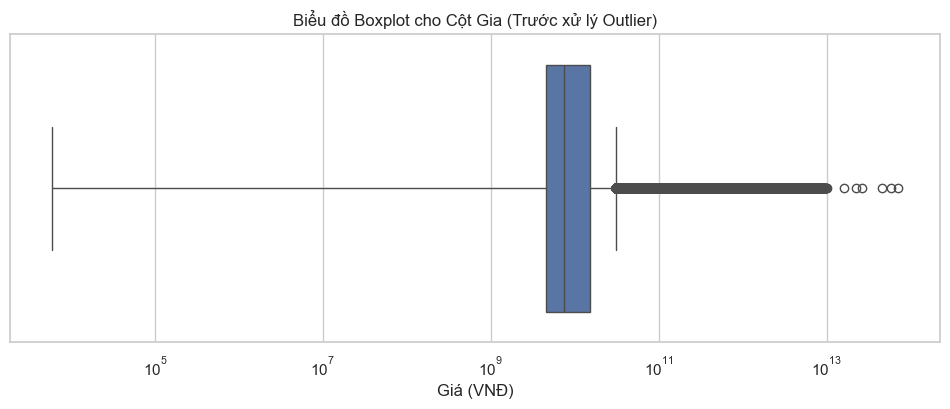

In [46]:
print("\n Bắt đầu kiểm tra Outliers bằng Boxplot...")
sns.set_theme(style="whitegrid")

# --- 1. Kiểm tra Cột 'Gia' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia'])
plt.title('Biểu đồ Boxplot cho Cột Gia (Trước xử lý Outlier)')
plt.xlabel('Giá (VNĐ)')
plt.xscale('log') # Dùng thang log
plt.show()

* Phần lớn giá nhà tập trung trong khoảng $10^{9}$ tỷ đến $10^{10}$ (vài chục tỷ VND)
* Xuất hiện các outliers cực lớn và phi lý (lên đến $10^{13}$ VND), cần được xem xét loại bỏ để việc phân tích chính xác hơn

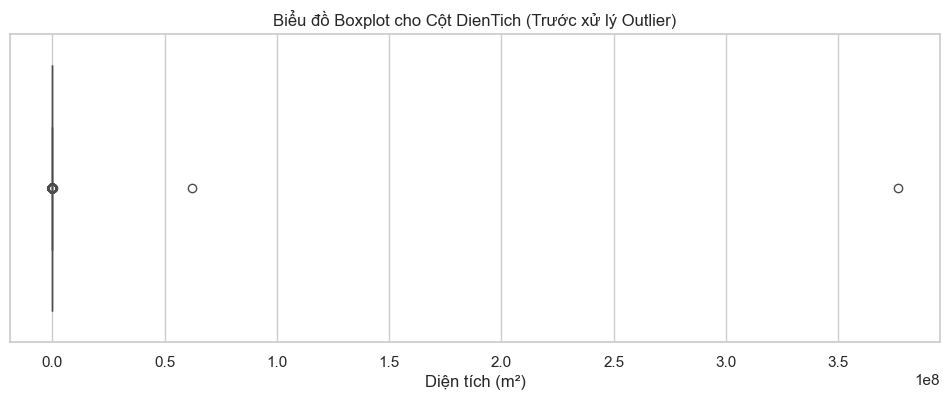

In [47]:
# --- 2. Kiểm tra Cột 'DienTich' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['DienTich'])
plt.title('Biểu đồ Boxplot cho Cột DienTich (Trước xử lý Outlier)')
plt.xlabel('Diện tích (m²)')
# Có thể dùng xlim để zoom nếu cần: plt.xlim(0, df_final['DienTich'].quantile(0.99) * 1.1)
plt.show()

* Một điểm ở khoảng 0.5 x 10⁸ ($50,000,000 \, m^2$ hay 50 km²)
* Một điểm khác ở gần 3.8 x 10⁸ ($380,000,000 \, m^2$ hay 380 km²).
* Những con số này cực kỳ lớn và phi thực tế đối với một tin rao bán bất động sản thông thường

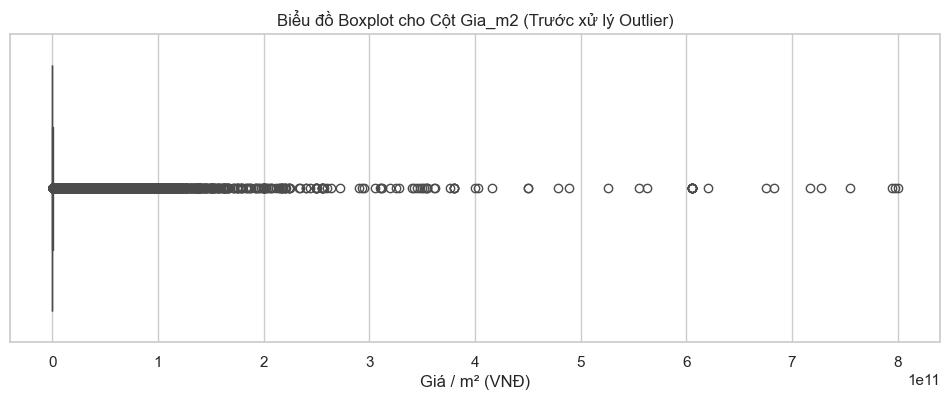

In [48]:
# --- 3. Kiểm tra Cột 'Gia_m2' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia_m2'])
plt.title('Biểu đồ Boxplot cho Cột Gia_m2 (Trước xử lý Outlier)')
plt.xlabel('Giá / m² (VNĐ)')
# Có thể dùng xlim để zoom: plt.xlim(0, df_final['Gia_m2'].quantile(0.99) * 1.1)
plt.show()



* Phần hộp và râu bị nén chặt về phía bên trái, gần giá trị 0.
* Có rất nhiều điểm dữ liệu nằm rải rác và rất xa về phía bên phải của biểu đồ.


#### **11.2. Loại bỏ Outliers**

In [49]:
# Backup trước khi xử lý
df_before_outlier = df_final.copy()
print(f" Shape trước xử lý outliers: {df_before_outlier.shape}")

# --- Xử lý outliers cho Giá (Gia) theo từng Loại BĐS ---
print("\n Xử lý outliers: Giá (theo phân vị 0.5% - 99.5% mỗi loại)")
df_temp_list_gia = []
for loai in df_final['LoaiBDS'].unique():
    if loai == 'CXD': # Bỏ qua loại không xác định
        df_temp_list_gia.append(df_final[df_final['LoaiBDS'] == loai])
        continue

    subset = df_final[(df_final['LoaiBDS'] == loai) & (df_final['Gia'] > 0)]
    n_before = len(subset)

    if n_before < 50: # Không xử lý nếu nhóm quá nhỏ
        df_temp_list_gia.append(subset)
        continue

    # Dùng percentile 0.5% - 99.5%
    lower = subset['Gia'].quantile(0.005)
    upper = subset['Gia'].quantile(0.995)

    # Lọc giữ lại dữ liệu trong khoảng
    subset_filtered = subset[(subset['Gia'] >= lower) & (subset['Gia'] <= upper)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_gia.append(subset_filtered)

    if n_outliers > 0:
        print(f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers ({n_outliers/n_before*100:5.2f}%) | Giới hạn: {lower/1e6:.1f} tr - {upper/1e9:.2f} tỷ")

# Ghép lại DataFrame sau khi xử lý Giá
df_final = pd.concat(df_temp_list_gia)
print(f" Shape sau xử lý outliers Giá: {df_final.shape}")


# --- Xử lý outliers cho Diện tích (DienTich) theo giới hạn cứng ---
print("\n Xử lý outliers: Diện tích (theo giới hạn cứng mỗi loại)")
limits_dientich = {
    'Căn hộ': (20, 500),
    'Nhà': (20, 1000), # Giảm min xuống 20
    'Đất': (30, 5000), # Giảm min xuống 30
    'Villa': (80, 2000), # Giảm min xuống 80
    'Shophouse': (30, 600),
    'Mặt bằng/Shop': (10, 1000),
    'Phòng trọ': (10, 100),
    'Kho/Xưởng': (50, 10000),
    'Khách sạn/Nhà nghỉ': (50, 5000)
    # Các loại khác hoặc CXD sẽ không bị lọc ở bước này
}

df_temp_list_dt = []
processed_loai = set()
for loai, (min_dt, max_dt) in limits_dientich.items():
    processed_loai.add(loai)
    subset = df_final[(df_final['LoaiBDS'] == loai) & (df_final['DienTich'] > 0)]
    n_before = len(subset)

    if n_before == 0: continue

    subset_filtered = subset[(subset['DienTich'] >= min_dt) & (subset['DienTich'] <= max_dt)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_dt.append(subset_filtered)

    if n_outliers > 0:
        print(f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers | Giới hạn: {min_dt}-{max_dt} m²")

# Thêm lại các loại không có trong limits hoặc CXD
unprocessed_loai = df_final[~df_final['LoaiBDS'].isin(processed_loai)]
df_temp_list_dt.append(unprocessed_loai)

# Ghép lại DataFrame sau khi xử lý Diện tích
df_final = pd.concat(df_temp_list_dt)
print(f" Shape sau xử lý outliers Diện tích: {df_final.shape}")


# --- Xử lý outliers cho Giá/m2 (Gia_m2) theo từng Loại BĐS ---
print("\n Xử lý outliers: Giá/m2 (theo phân vị 1% - 99% mỗi loại)")
df_temp_list_giam2 = []
for loai in df_final['LoaiBDS'].unique():
    if loai == 'CXD':
        df_temp_list_giam2.append(df_final[df_final['LoaiBDS'] == loai])
        continue

    subset = df_final[(df_final['LoaiBDS'] == loai) & (df_final['Gia_m2'] > 0)]
    n_before = len(subset)

    if n_before < 50:
        df_temp_list_giam2.append(subset)
        continue

    # Dùng percentile 1% - 99%
    lower = subset['Gia_m2'].quantile(0.01)
    upper = subset['Gia_m2'].quantile(0.99)

    subset_filtered = subset[(subset['Gia_m2'] >= lower) & (subset['Gia_m2'] <= upper)]
    n_after = len(subset_filtered)
    n_outliers = n_before - n_after

    df_temp_list_giam2.append(subset_filtered)

    if n_outliers > 0:
        print(f"  • {loai:<15s}: Loại bỏ {n_outliers:5,} outliers | Giới hạn: {lower/1e6:.1f} tr/m² - {upper/1e6:.1f} tr/m²")

# Ghép lại DataFrame sau khi xử lý Giá/m2
df_final = pd.concat(df_temp_list_giam2)
print(f" Shape sau xử lý outliers Giá/m2: {df_final.shape}")


# --- Tổng kết xử lý Outliers ---
print("\n" + "="*60)
print(" HOÀN TẤT XỬ LÝ OUTLIERS")
print("="*60)
print(f" Shape ban đầu (trước outlier): {df_before_outlier.shape}")
print(f" Shape cuối cùng (sau outlier):  {df_final.shape}")
removed_count = len(df_before_outlier) - len(df_final)
removed_pct = removed_count / len(df_before_outlier) * 100 if len(df_before_outlier) > 0 else 0
print(f"  Đã loại bỏ tổng cộng:       {removed_count:,} dòng ({removed_pct:.2f}%) do outliers.")

print("\n Xử lý Outliers hoàn tất.")

 Shape trước xử lý outliers: (122067, 19)

 Xử lý outliers: Giá (theo phân vị 0.5% - 99.5% mỗi loại)
  • Nhà            : Loại bỏ   688 outliers ( 1.00%) | Giới hạn: 450.0 tr - 1980.00 tỷ
  • Đất            : Loại bỏ   243 outliers ( 1.00%) | Giới hạn: 130.0 tr - 3457.30 tỷ
  • Không xác định : Loại bỏ   117 outliers ( 0.99%) | Giới hạn: 570.2 tr - 460.00 tỷ
  • Căn hộ         : Loại bỏ   121 outliers ( 1.01%) | Giới hạn: 146.3 tr - 232.00 tỷ
  • Biệt thự       : Loại bỏ    52 outliers ( 1.02%) | Giới hạn: 3548.2 tr - 402.33 tỷ
 Shape sau xử lý outliers Giá: (120846, 19)

 Xử lý outliers: Diện tích (theo giới hạn cứng mỗi loại)
  • Căn hộ         : Loại bỏ    63 outliers | Giới hạn: 20-500 m²
  • Nhà            : Loại bỏ 1,146 outliers | Giới hạn: 20-1000 m²
  • Đất            : Loại bỏ 1,200 outliers | Giới hạn: 30-5000 m²
 Shape sau xử lý outliers Diện tích: (118437, 19)

 Xử lý outliers: Giá/m2 (theo phân vị 1% - 99% mỗi loại)
  • Căn hộ         : Loại bỏ   238 outliers | Giới hạn: 

#### **11.3. Trực quan hóa Outliers (Sau khi xử lý)**

*Vẽ lại biểu đồ boxplot để xem hiệu quả của việc loại bỏ outlier.*

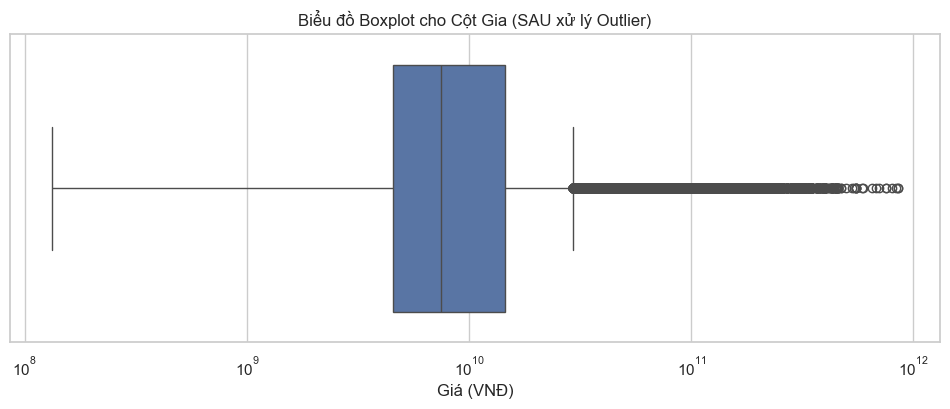

In [50]:
# --- 1. Kiểm tra Cột 'Gia' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia'])
plt.title('Biểu đồ Boxplot cho Cột Gia (SAU xử lý Outlier)')
plt.xlabel('Giá (VNĐ)')
plt.xscale('log')
plt.show()

* Giá trị cao nhất của các outliers này chỉ đến khoảng $10^{12}$ (một nghìn tỷ) VND, thay vì $10^{13}$ (mười nghìn tỷ) như trước

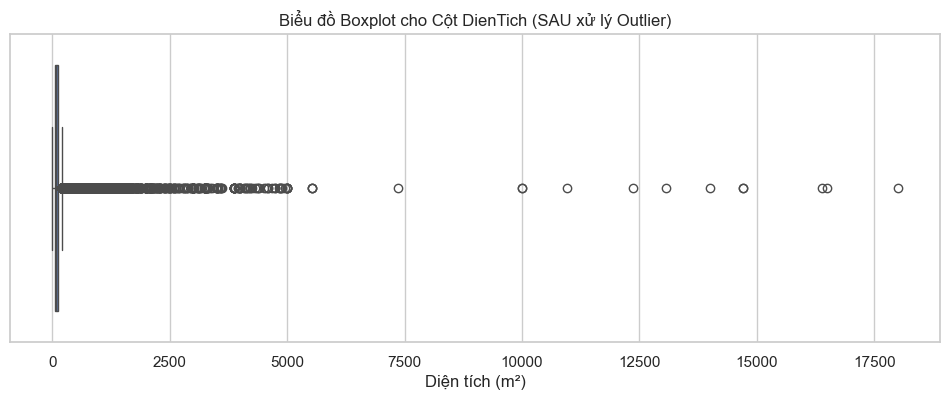

In [51]:
# --- 2. Kiểm tra Cột 'DienTich' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['DienTich'])
plt.title('Biểu đồ Boxplot cho Cột DienTich (SAU xử lý Outlier)')
plt.xlabel('Diện tích (m²)')
plt.show()

* Cái hộp (IQR - chứa 50% dữ liệu giữa) nằm ở khoảng diện tích tương đối nhỏ (có thể từ vài chục đến vài trăm m²).

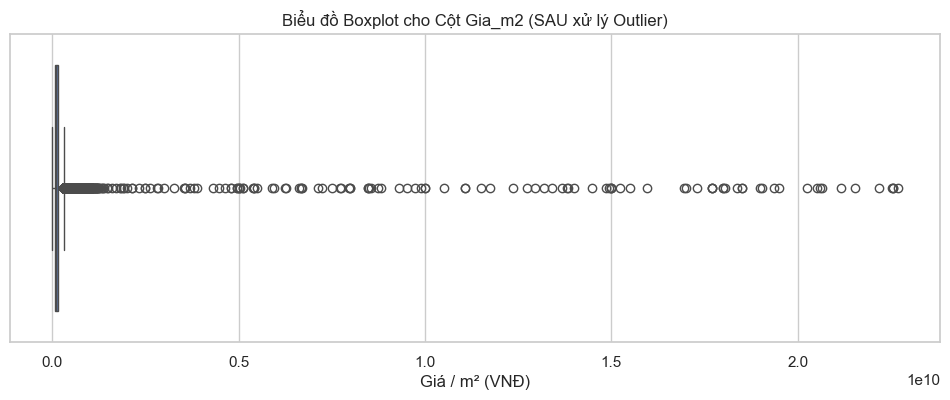

In [52]:
# --- 3. Kiểm tra Cột 'Gia_m2' ---
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_final['Gia_m2'])
plt.title('Biểu đồ Boxplot cho Cột Gia_m2 (SAU xử lý Outlier)')
plt.xlabel('Giá / m² (VNĐ)')
plt.show()

* Vẫn còn khá nhiều outliers ở phía bên phải.
* Tuy nhiên, giá trị cao nhất của các outliers này (khoảng 20 tỷ VND/m²) đã thấp hơn rất nhiều so với trước khi xử lý (lên đến 800 tỷ VND/m²).
* Những outliers còn lại này, dù vẫn cao, nhưng có khả năng là giá thực tế của các bất động sản ở những vị trí cực kỳ đắc địa

### **12. Xuất Kết Quả**

*Lưu DataFrame `df_final` đã được làm sạch và xử lý ra file CSV mới.*

In [53]:
output_filename = r'fulldata_clean_4web.csv' 
print("\n Bắt đầu xuất DataFrame cuối cùng ra file CSV")

df_final.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(" HOÀN TẤT TIỀN XỬ LÝ!")

print(f" File kết quả: {output_filename}")
print(f" Shape cuối cùng: {df_final.shape}")




 Bắt đầu xuất DataFrame cuối cùng ra file CSV
 HOÀN TẤT TIỀN XỬ LÝ!
 File kết quả: fulldata_clean_4web.csv
 Shape cuối cùng: (116063, 19)
